<a href="https://colab.research.google.com/github/Thujaina/ECG-classification---AlexNet/blob/main/sparse_categorical_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from keras.models import Model
from keras.layers import Input
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"
train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


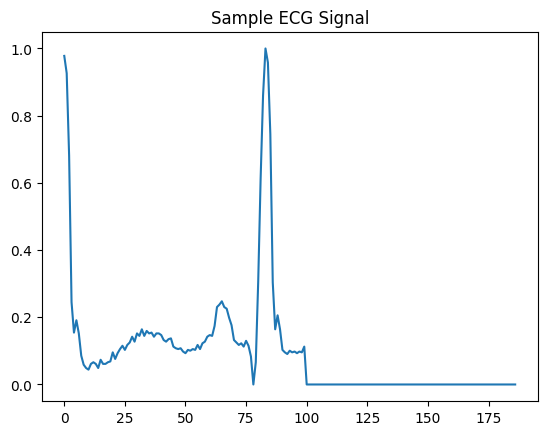

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

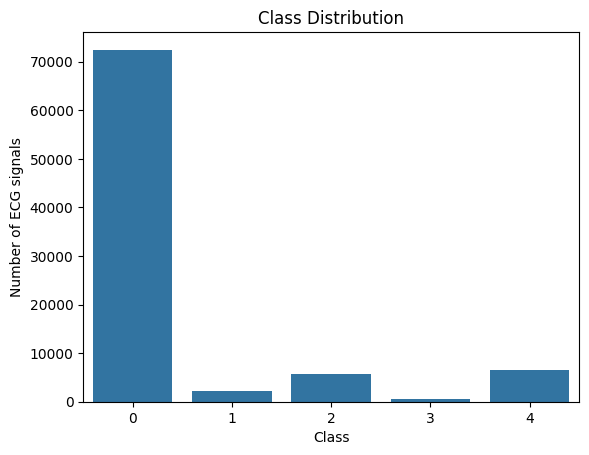

In [6]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [7]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [8]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [9]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [10]:
print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [11]:
X_res = X_res[:120000]
y_res = y_res[:120000]

In [16]:
# No one-hot encoding needed for sparse loss
y_res_sparse = y_res
y_test_sparse = y_test

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_sparse, test_size=0.2, random_state=42
)

In [18]:
X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [19]:
def alexnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(96, kernel_size=11, strides=4, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)

    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Flatten()(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',  # ✅ CHANGED
        metrics=['accuracy']
    )

    return model

In [21]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []
X_res = np.array(X_res).reshape(-1,187,1)

In [22]:
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr = y_res[train_idx]
    y_va = y_res[val_idx]

    model = alexnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=128,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)


Fold 1
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 496ms/step - accuracy: 0.8598 - loss: 0.3916
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 328s 507ms/step - accuracy: 0.9521 - loss: 0.1446
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 311s 488ms/step - accuracy: 0.9671 - loss: 0.1007
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 488ms/step - accuracy: 0.9747 - loss: 0.0785
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - accuracy: 0.9791 - loss: 0.0639
Fold 1 Accuracy: 0.9724

Fold 2
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 311s 493ms/step - accuracy: 0.8644 - loss: 0.3794
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 493ms/step - accuracy: 0.9534 - loss: 0.1402
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 308s 493ms/step - accuracy: 0.9684 - loss: 0.0963
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 307s 491ms/step - accuracy: 0.9760 - loss: 0.0748
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - accuracy: 0.9792 - loss: 0.0657
Fold 2 Accuracy: 0.9797

Fold 3
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━

In [23]:
print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Cross-validation accuracies: [0.9724000096321106, 0.9797499775886536, 0.9815999865531921]
Mean CV accuracy: 0.9779166579246521


In [24]:
model = alexnet_ecg()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 398s 524ms/step - accuracy: 0.8743 - loss: 0.3456 - val_accuracy: 0.9480 - val_loss: 0.1424
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 436s 515ms/step - accuracy: 0.9581 - loss: 0.1259 - val_accuracy: 0.9609 - val_loss: 0.1132
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 385s 513ms/step - accuracy: 0.9720 - loss: 0.0870 - val_accuracy: 0.9740 - val_loss: 0.0758
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 390s 520ms/step - accuracy: 0.9782 - loss: 0.0671 - val_accuracy: 0.9761 - val_loss: 0.0701
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 436s 512ms/step - accuracy: 0.9818 - loss: 0.0568 - val_accuracy: 0.9813 - val_loss: 0.0556
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 385s 514ms/step - accuracy: 0.9845 - loss: 0.0490 - val_accuracy: 0.9833 - val_loss: 0.0518
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 442s 514ms/step - accuracy: 0.9858 - loss: 0.0441 - val_accuracy: 0.9853 - val_loss: 0.0481
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 386s 515ms/step - accuracy: 0.9877 -

In [27]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = y_val

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)

750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step
Validation MCC: 0.9771128685844352


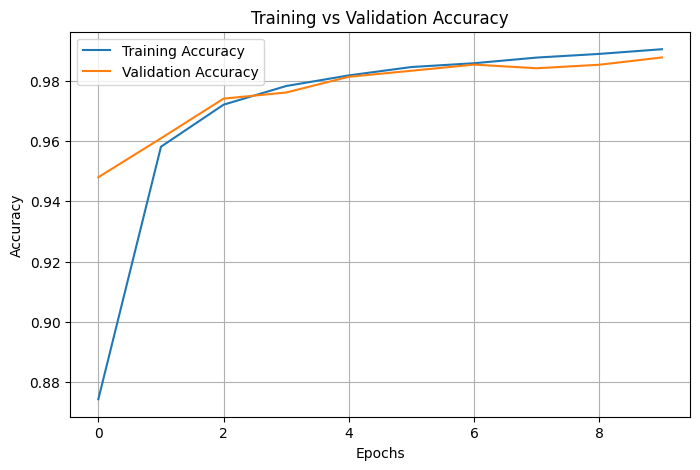

Final Training Accuracy: 0.9904
Final Validation Accuracy: 0.9877


In [28]:
# Cell 24: Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

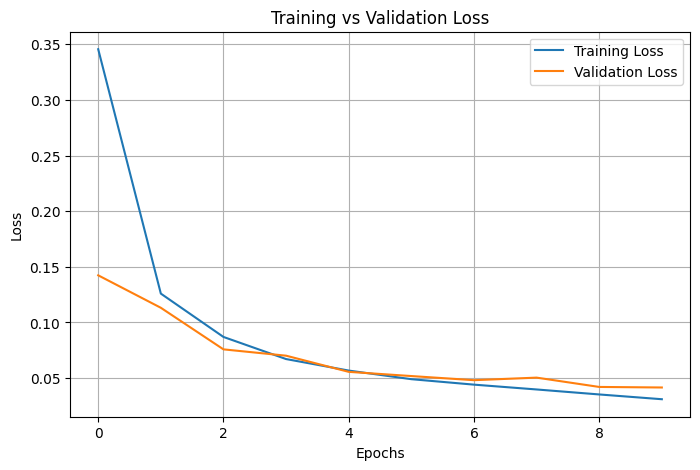

Final Training Loss: 0.0310
Final Validation Loss: 0.0415


In [29]:
# Cell 25: Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

In [30]:
test_loss, test_acc = model.evaluate(X_test, y_test_sparse, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0933
Test Accuracy: 0.9832


In [31]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.82      0.83      0.82       556
         2.0       0.96      0.95      0.95      1448
         3.0       0.89      0.70      0.78       162
         4.0       0.99      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.93      0.89      0.91     21892
weighted avg       0.98      0.98      0.98     21892



In [32]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
num_classes = cm.shape[0]

# Lists
precision = []
recall = []
f1 = []
specificity = []
support = []

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    prec = TP / (TP + FP) if (TP + FP) != 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) != 0 else 0
    spec = TN / (TN + FP) if (TN + FP) != 0 else 0
    f1_score = (2 * prec * rec) / (prec + rec) if (prec + rec) != 0 else 0

    precision.append(prec)
    recall.append(rec)
    f1.append(f1_score)
    specificity.append(spec)
    support.append(np.sum(cm[i, :]))

# Convert to numpy
precision = np.array(precision)
recall = np.array(recall)
f1 = np.array(f1)
specificity = np.array(specificity)
support = np.array(support)

# Accuracy
accuracy = np.trace(cm) / np.sum(cm)

# Macro Average
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)
macro_spec = np.mean(specificity)

# Weighted Average
weights = support / np.sum(support)

weighted_precision = np.sum(precision * weights)
weighted_recall = np.sum(recall * weights)
weighted_f1 = np.sum(f1 * weights)
weighted_spec = np.sum(specificity * weights)

# Create DataFrame
report_df = pd.DataFrame({
    "precision": precision,
    "recall": recall,
    "f1-score": f1,
    "specificity": specificity,
    "support": support
})

report_df.index = [f"Class {i}" for i in range(num_classes)]

# Add summary rows
summary_df = pd.DataFrame({
    "precision": [accuracy, macro_precision, weighted_precision],
    "recall":    [accuracy, macro_recall, weighted_recall],
    "f1-score":  [accuracy, macro_f1, weighted_f1],
    "specificity": [np.nan, macro_spec, weighted_spec],
    "support":   [np.sum(support), np.sum(support), np.sum(support)]
}, index=["accuracy", "macro avg", "weighted avg"])

# Combine
final_df = pd.concat([report_df, summary_df])

# Print
print(final_df.round(3))

685/685 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step
              precision  recall  f1-score  specificity  support
Class 0           0.991   0.992     0.992        0.955    18118
Class 1           0.815   0.833     0.824        0.995      556
Class 2           0.956   0.952     0.954        0.997     1448
Class 3           0.890   0.698     0.782        0.999      162
Class 4           0.990   0.988     0.989        0.999     1608
accuracy          0.983   0.983     0.983          NaN    21892
macro avg         0.928   0.893     0.908        0.989    21892
weighted avg      0.983   0.983     0.983        0.963    21892


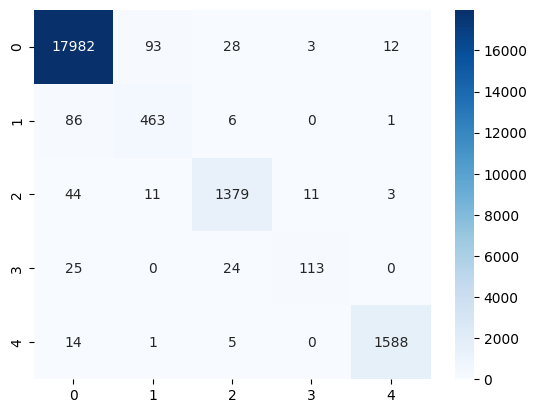

In [33]:
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()